<a href="https://colab.research.google.com/github/overwatch093-alt/Applied-Data-Science-1/blob/main/ADS1_Tutorial_2_1_Reading_Files.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#1) Manually (inbuilt python methods)
with open('countries_top10.csv', 'r') as f:
    data = []
    for line in f.readlines():
        linelist = line.rstrip('\n').split(',')
        for i, value in enumerate(linelist):
            try:
                value = float(value)
                if value.is_integer():
                    value = int(value)
            except ValueError:
                continue
            linelist[i] = value
        data.append(linelist)
print(data)
print(type(data))
print(type(data[0]))
print(type(data[1][1]))

[['Country', 'Population', 'Area', 'GDP'], ['Bangladesh', 160996000, 147570, 195100000000], ['Brasil', 207848000, 8547404, 1775000000000], ['China', 1379113000, 9572419, 10866000000000], ['India', 1311051000, 3287263, 2047000000000], ['Indonesia', 257564000, 1912988, 861900000000], ['Mexico', 127017000, 1359162, 1144000000000], ['Nigeria', 182202000, 923768, 481100000000], ['Pakistan', 188925000, 796095, 270000000000], ['Russia', 144097000, 17075400, 1326000000000], ['USA', 321419000, 9809155, 17947000000000]]
<class 'list'>
<class 'list'>
<class 'int'>


In [2]:
# CSV method (standard library)
import csv
with open('countries_top10.csv', 'r') as f:
    csvreader = csv.reader(f)
    data = []
    for row in csvreader:
        for i, value in enumerate(row):
            try:
                value = float(value)
                if value.is_integer():
                    value = int(value)
            except ValueError:
                continue
            row[i] = value
        data.append(row)
print(data)
print(type(data))
print(type(data[0]))
print(type(data[1][1]))

[['Country', 'Population', 'Area', 'GDP'], ['Bangladesh', 160996000, 147570, 195100000000], ['Brasil', 207848000, 8547404, 1775000000000], ['China', 1379113000, 9572419, 10866000000000], ['India', 1311051000, 3287263, 2047000000000], ['Indonesia', 257564000, 1912988, 861900000000], ['Mexico', 127017000, 1359162, 1144000000000], ['Nigeria', 182202000, 923768, 481100000000], ['Pakistan', 188925000, 796095, 270000000000], ['Russia', 144097000, 17075400, 1326000000000], ['USA', 321419000, 9809155, 17947000000000]]
<class 'list'>
<class 'list'>
<class 'int'>


In [3]:
# pandas
import pandas as pd
df = pd.read_csv('countries_top10.csv')
print(df)
print(type(df))
print(type(df.iloc[0]))
print(type(df.iloc[1, 1]))
# or preferably
print(df['Population'][1])

      Country  Population      Area             GDP
0  Bangladesh   160996000    147570    195100000000
1      Brasil   207848000   8547404   1775000000000
2       China  1379113000   9572419  10866000000000
3       India  1311051000   3287263   2047000000000
4   Indonesia   257564000   1912988    861900000000
5      Mexico   127017000   1359162   1144000000000
6     Nigeria   182202000    923768    481100000000
7    Pakistan   188925000    796095    270000000000
8      Russia   144097000  17075400   1326000000000
9         USA   321419000   9809155  17947000000000
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>
<class 'numpy.int64'>
207848000


In [4]:
# numpy method(s)
import numpy as np
data = np.genfromtxt('countries_top10.csv', dtype=[('Country', 'S10'), ('Population', int), ('Area', int), ('GDP', int)],
                     delimiter=',', skip_header=1)
# or data = np.loadtxt -- if you know there is no missing data
print(data)
print(type(data))
print(type(data[0]))
print(type(data[1][1]))

[(b'Bangladesh',  160996000,   147570,   195100000000)
 (b'Brasil',  207848000,  8547404,  1775000000000)
 (b'China', 1379113000,  9572419, 10866000000000)
 (b'India', 1311051000,  3287263,  2047000000000)
 (b'Indonesia',  257564000,  1912988,   861900000000)
 (b'Mexico',  127017000,  1359162,  1144000000000)
 (b'Nigeria',  182202000,   923768,   481100000000)
 (b'Pakistan',  188925000,   796095,   270000000000)
 (b'Russia',  144097000, 17075400,  1326000000000)
 (b'USA',  321419000,  9809155, 17947000000000)]
<class 'numpy.ndarray'>
<class 'numpy.void'>
<class 'numpy.int64'>


In [5]:
df = pd.read_csv('countries_top10.csv', index_col='Country')
df['GDP/head'] = df['GDP'] / df['Population']
df['Pop/km2'] = df['Population'] / df['Area']
df.head()

,Population,Area,GDP,GDP/head,Pop/km2
Country,,,,,
Bangladesh,160996000,147570,195100000000,1211.831350,1090.980552
Brasil,207848000,8547404,1775000000000,8539.894538,24.317091
China,1379113000,9572419,10866000000000,7878.977285,144.071525
India,1311051000,3287263,2047000000000,1561.342770,398.827535
Indonesia,257564000,1912988,861900000000,3346.352751,134.639632


             China       Germany         Japan  United States
Year                                                         
1970  2.320617e+11  1.398222e+12  1.460289e+12   5.183548e+12
1971  2.484453e+11  1.442024e+12  1.528908e+12   5.354261e+12
1972  2.579111e+11  1.504036e+12  1.657543e+12   5.635836e+12
1973  2.779250e+11  1.575891e+12  1.790687e+12   5.954020e+12
1974  2.843450e+11  1.589918e+12  1.768747e+12   5.921835e+12


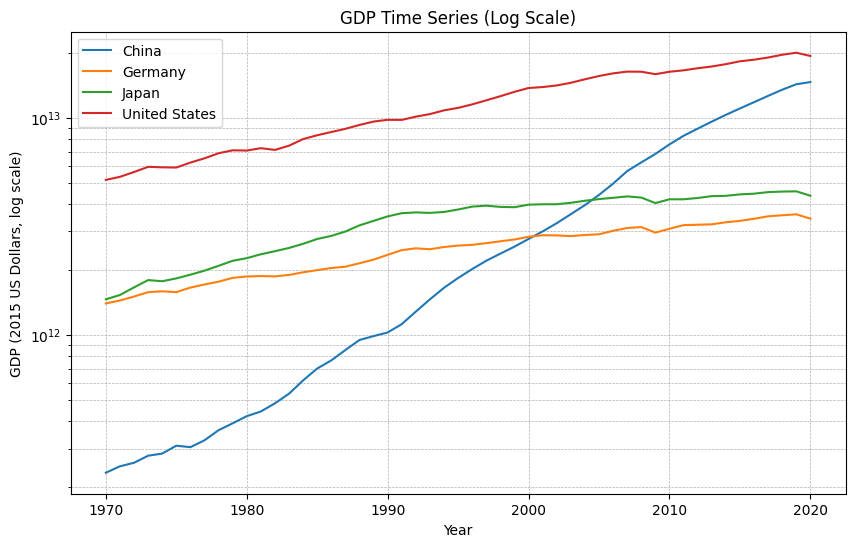

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Read CSV and set 'Year' (or the exact year column header) as index
df_gdp = pd.read_csv('GDP_2015dollars.csv', index_col='Year')
print(df_gdp.head())

# 2. Define the plotting function
def plot_yearly_gdp(df_gdp):
    """
    Plots the time series data for 4 countries GDP on a log scale.
    Hint: use a for loop across df_gdp.columns to save repeating similar lines of code.
    Set X axis to 'Year' and Y axis to 'GDP' in log scale.
    """
    plt.figure(figsize=(10, 6))

    # Loop through each country column and plot against df_gdp.index
    for country in df_gdp.columns:
        plt.plot(df_gdp.index, df_gdp[country], label=country)

    plt.yscale('log')
    plt.xlabel('Year')
    plt.ylabel('GDP (2015 US Dollars, log scale)')
    plt.title('GDP Time Series (Log Scale)')
    plt.legend()
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.show()

# 3. Call the function
plot_yearly_gdp(df_gdp)

             China       Germany         Japan  United States  China_rel  \
Year                                                                       
1970  2.320617e+11  1.398222e+12  1.460289e+12   5.183548e+12   4.476890   
1971  2.484453e+11  1.442024e+12  1.528908e+12   5.354261e+12   4.640142   
1972  2.579111e+11  1.504036e+12  1.657543e+12   5.635836e+12   4.576270   
1973  2.779250e+11  1.575891e+12  1.790687e+12   5.954020e+12   4.667854   
1974  2.843450e+11  1.589918e+12  1.768747e+12   5.921835e+12   4.801637   

      Germany_rel  Japan_rel  United States_rel  
Year                                             
1970    26.974226  28.171605              100.0  
1971    26.932273  28.554971              100.0  
1972    26.687008  29.410772              100.0  
1973    26.467684  30.075256              100.0  
1974    26.848394  29.868215              100.0  


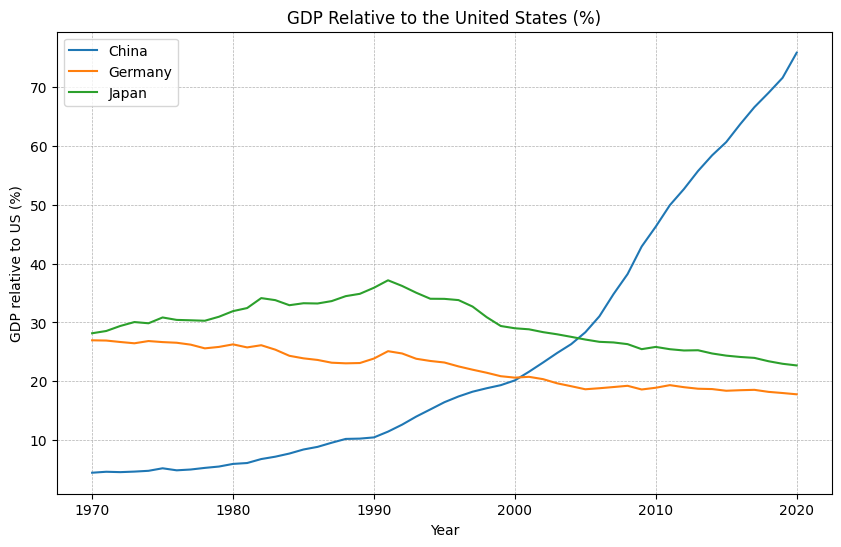

In [8]:
# 1. Read CSV again to start fresh
df_gdp = pd.read_csv('GDP_2015dollars.csv', index_col='Year')

# 2. Identify the US column name (typically 'United States' or 'USA')
us_col = 'United States' if 'United States' in df_gdp.columns else 'USA'

# Compute GDP relative to the US as a percentage
for country in df_gdp.columns:
    df_gdp[country + '_rel'] = (df_gdp[country] / df_gdp[us_col]) * 100

print(df_gdp.head())

# 3. Define function to plot the other 3 countries relative to the US
def plot_yearly_gdp_relative(df_gdp):
    """
    Plots the time series data for 3 countries GDP relative to the US, on a linear scale.
    """
    plt.figure(figsize=(10, 6))

    # Plot relative columns, excluding the US relative column itself (which is 100%)
    for col in df_gdp.columns:
        if col.endswith('_rel') and col != f'{us_col}_rel':
            country_name = col.replace('_rel', '')
            plt.plot(df_gdp.index, df_gdp[col], label=country_name)

    plt.xlabel('Year')
    plt.ylabel('GDP relative to US (%)')
    plt.title('GDP Relative to the United States (%)')
    plt.legend()
    plt.grid(True, linestyle='--', linewidth=0.5)
    plt.show()

# 4. Call the function
plot_yearly_gdp_relative(df_gdp)